# **EEG-Seizure-Detection_MLProject_SHAYAN**

In [17]:
# %pip install imbalanced-learn

In [18]:
import os
import math
import imblearn
import logging
import warnings
import statistics
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score , accuracy_score , precision_score, recall_score ,confusion_matrix
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from numpy import genfromtxt
from mpl_toolkits.mplot3d import Axes3D
from imblearn.combine import SMOTEENN
%matplotlib inline

In [19]:
from warnings import simplefilter
simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore')

In [20]:
path = r"C:\Users\User\Desktop\Epileptic Seizure Recognition_ML project_Shayan\Epileptic Seizure Recognition.csv"

In [21]:
data = pd.read_csv(path)

In [22]:
data.head()

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [23]:
data.describe()
#finding out the summary of the dataset

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
count,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.00000,11500.00000,11500.000000,...,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000
mean,-11.581391,-10.911565,-10.187130,-9.143043,-8.009739,-7.003478,-6.502087,-6.68713,-6.55800,-6.168435,...,-10.145739,-11.630348,-12.943478,-13.668870,-13.363304,-13.045043,-12.705130,-12.426000,-12.195652,3.000000
std,165.626284,166.059609,163.524317,161.269041,160.998007,161.328725,161.467837,162.11912,162.03336,160.436352,...,164.652883,166.149790,168.554058,168.556486,167.257290,164.241019,162.895832,162.886311,164.852015,1.414275
min,-1839.000000,-1838.000000,-1835.000000,-1845.000000,-1791.000000,-1757.000000,-1832.000000,-1778.00000,-1840.00000,-1867.000000,...,-1867.000000,-1865.000000,-1642.000000,-1723.000000,-1866.000000,-1863.000000,-1781.000000,-1727.000000,-1829.000000,1.000000
25%,-54.000000,-55.000000,-54.000000,-54.000000,-54.000000,-54.000000,-54.000000,-55.00000,-55.00000,-54.000000,...,-55.000000,-56.000000,-56.000000,-56.000000,-55.000000,-56.000000,-55.000000,-55.000000,-55.000000,2.000000
50%,-8.000000,-8.000000,-7.000000,-8.000000,-8.000000,-8.000000,-8.000000,-8.00000,-7.00000,-7.000000,...,-9.000000,-10.000000,-10.000000,-10.000000,-10.000000,-9.000000,-9.000000,-9.000000,-9.000000,3.000000
75%,34.000000,35.000000,36.000000,36.000000,35.000000,36.000000,35.000000,36.00000,36.00000,35.250000,...,34.000000,34.000000,33.000000,33.000000,34.000000,34.000000,34.000000,34.000000,34.000000,4.000000
max,1726.000000,1713.000000,1697.000000,1612.000000,1518.000000,1816.000000,2047.000000,2047.00000,2047.00000,2047.000000,...,1777.000000,1472.000000,1319.000000,1436.000000,1733.000000,1958.000000,2047.000000,2047.000000,1915.000000,5.000000


In [24]:
data.shape

(11500, 180)

In [25]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Columns: 180 entries, Unnamed to y
dtypes: int64(179), str(1)
memory usage: 15.9 MB


In [26]:
data.describe(include=object)

,Unnamed
count,11500
unique,11500
top,X21.V1.791
freq,1


In [27]:
null_values = data.isnull().sum()
null_values.to_numpy() #as we can see that there are no null values present on the dataset

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0])

In [28]:
data_1 = data.copy()

In [29]:
data_1.drop(['Unnamed','y'],axis=1,inplace=True)

In [30]:
data_1 

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X169,X170,X171,X172,X173,X174,X175,X176,X177,X178
0,135,190,229,223,192,125,55,-9,-33,-38,...,8,-17,-15,-31,-77,-103,-127,-116,-83,-51
1,386,382,356,331,320,315,307,272,244,232,...,168,164,150,146,152,157,156,154,143,129
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,...,29,57,64,48,19,-12,-30,-35,-35,-36
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,...,-80,-82,-81,-80,-77,-85,-77,-72,-69,-65
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,...,10,4,2,-12,-32,-41,-65,-83,-89,-73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11495,-22,-22,-23,-26,-36,-42,-45,-42,-45,-49,...,20,15,16,12,5,-1,-18,-37,-47,-48
11496,-47,-11,28,77,141,211,246,240,193,136,...,-94,-65,-33,-7,14,27,48,77,117,170
11497,14,6,-13,-16,10,26,27,-9,4,14,...,-42,-65,-48,-61,-62,-67,-30,-2,-1,-8
11498,-40,-25,-9,-12,-2,12,7,19,22,29,...,114,121,135,148,143,116,86,68,59,55


In [31]:
data['y'].value_counts()


y
4    2300
1    2300
5    2300
2    2300
3    2300
Name: count, dtype: int64

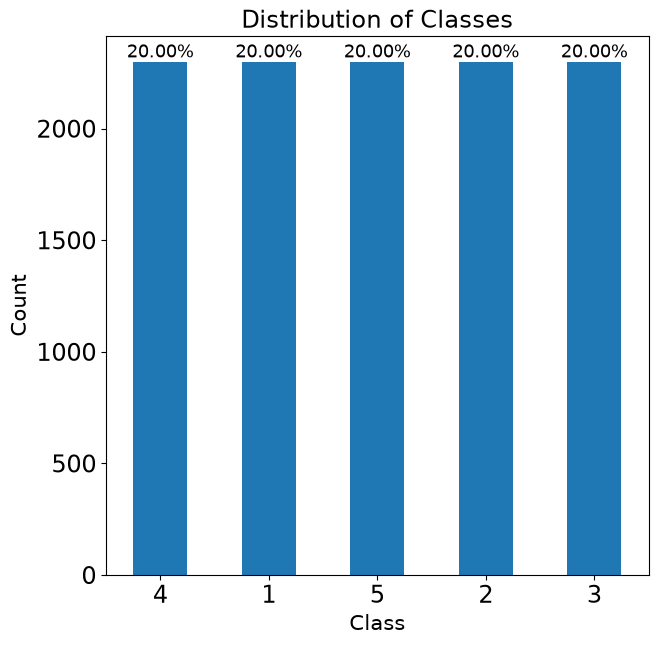

In [76]:
# visualizing the only categorical column present in the dataset
values = data['y'].value_counts()

plt.figure(figsize=(7,7))

ax = values.plot(kind='bar', fontsize=17)

plt.xlabel('Class', fontsize=15)
plt.ylabel('Count', fontsize=15)
plt.title('Distribution of Classes', fontsize=17)
plt.xticks(rotation=0)

total = values.sum()

for i, value in enumerate(values):
    percentage = (value / total) * 100
    ax.text(i, value, f'{percentage:.2f}%',
            ha='center', va='bottom', fontsize=13)

plt.show()

# It means all the categorical values in our dataset contain an equal amount of balance.

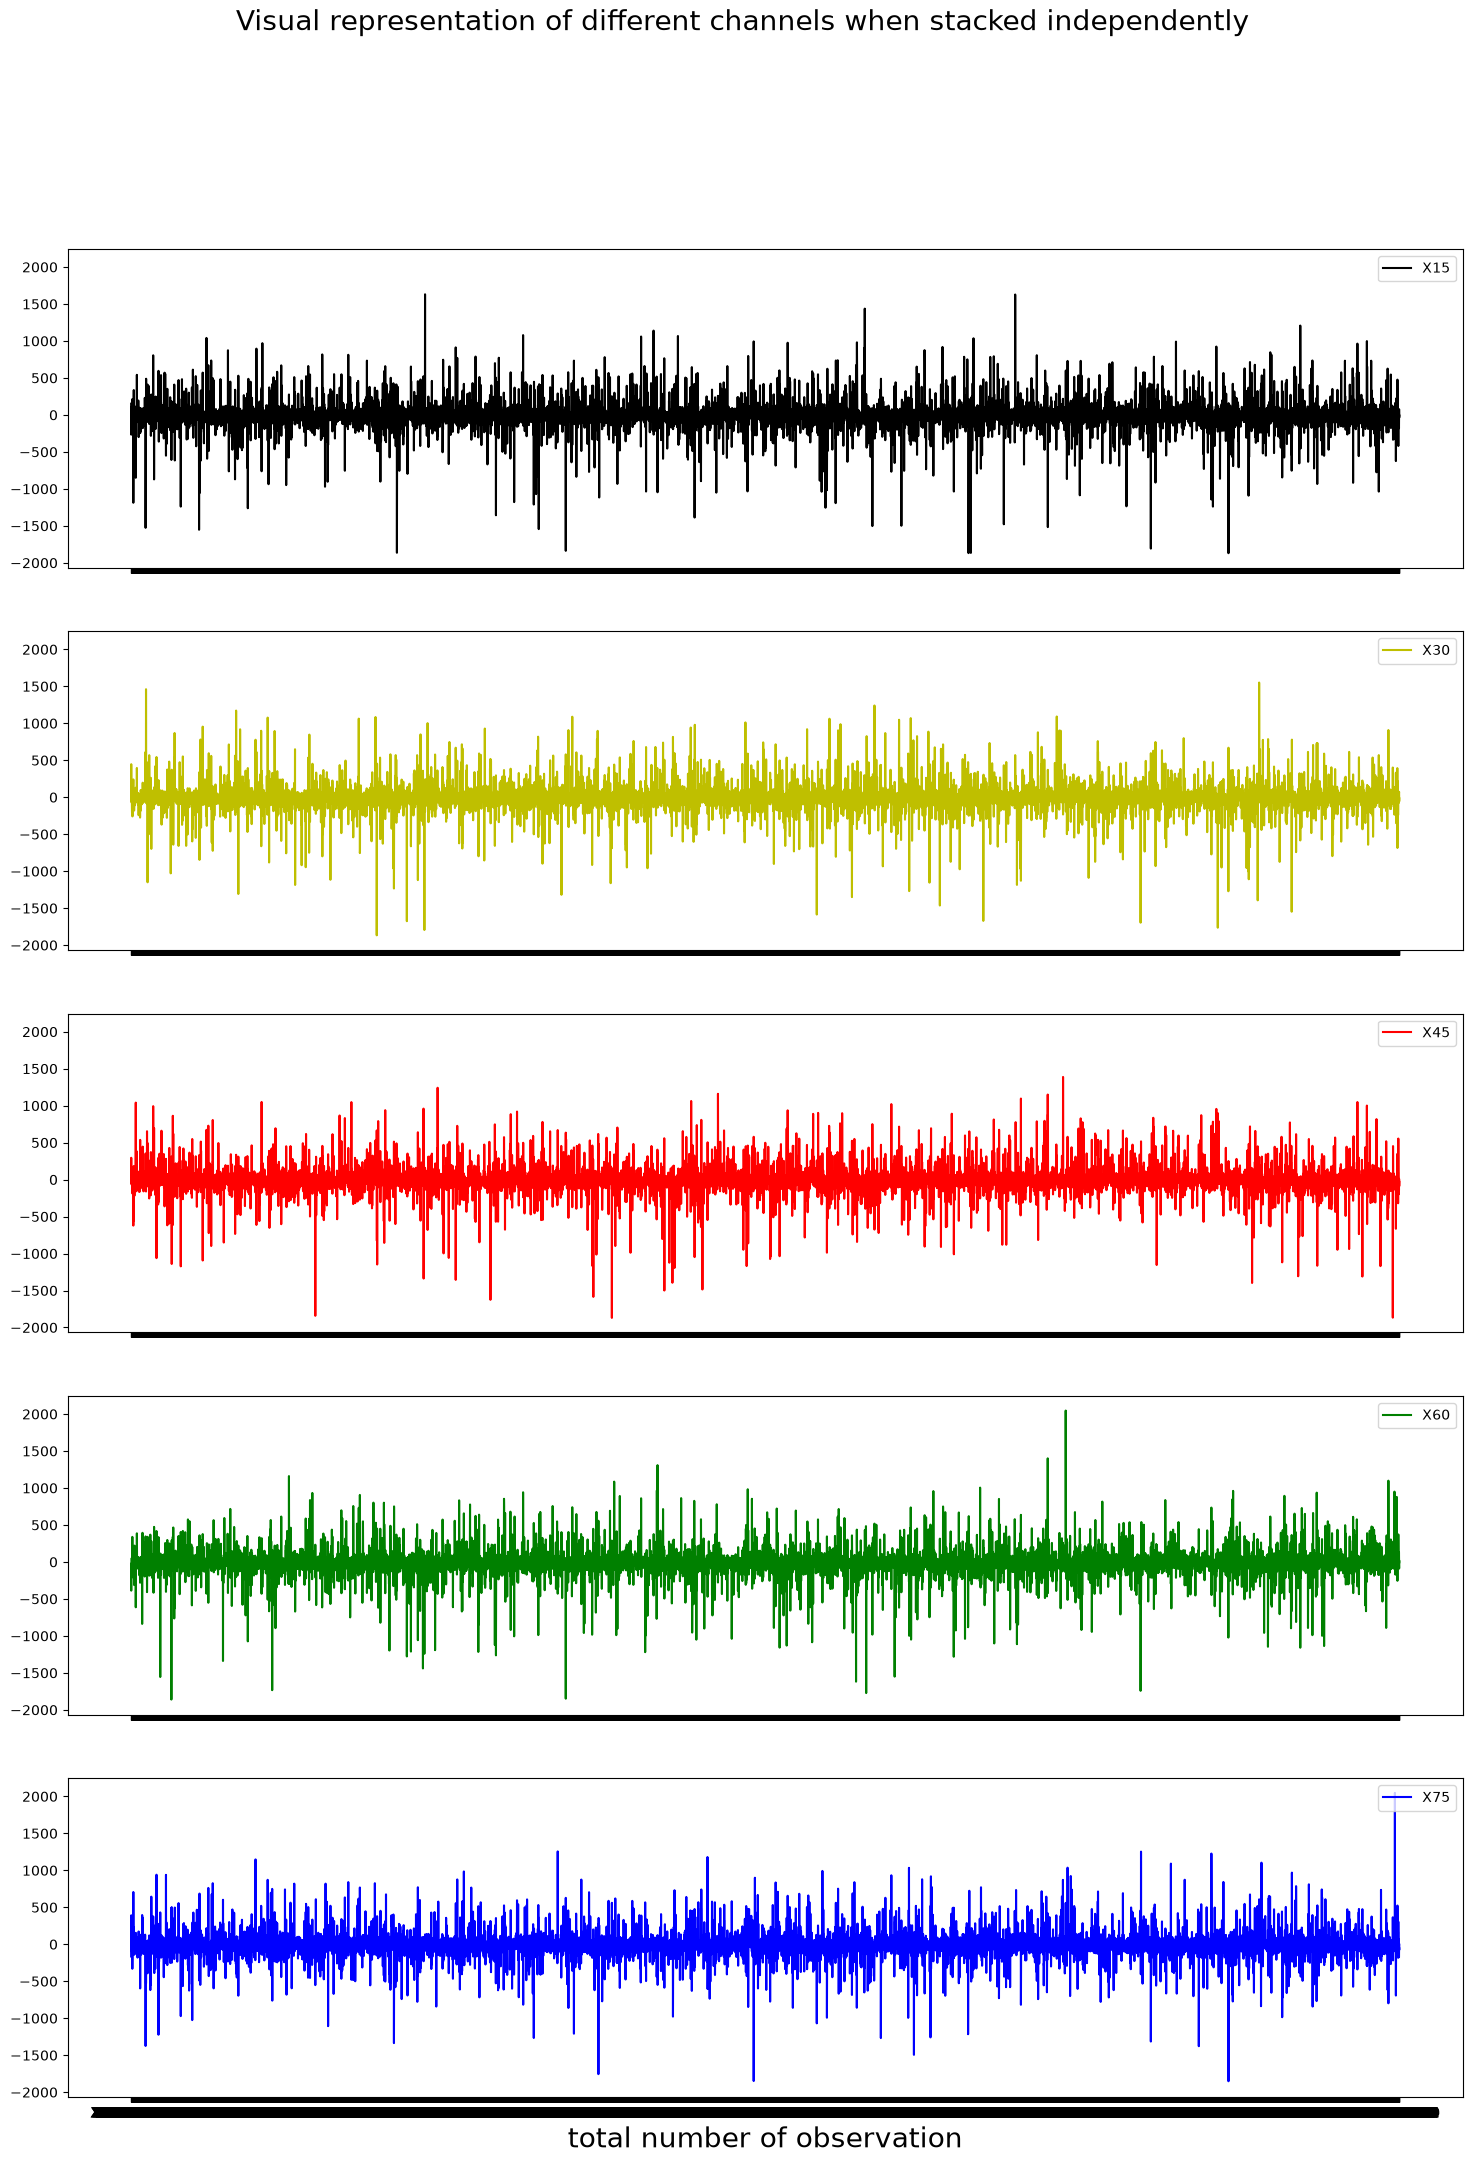

In [78]:
# plot these features in the same graph with stack plot
fig, axs = plt.subplots(5, sharex=True, sharey=True)
fig.set_size_inches(18, 24)
labels = ["X15","X30","X45","X60","X75"]
colors = ["k","y","r",'g',"b"]
fig.suptitle('Visual representation of different channels when stacked independently', fontsize = 20)
# loop over axes
for i,ax in enumerate(axs):
  axs[i].plot(data.iloc[:,0],data[labels[i]],color=colors[i],label=labels[i])
  axs[i].legend(loc="upper right")

plt.xlabel('total number of observation', fontsize = 20)
plt.show()

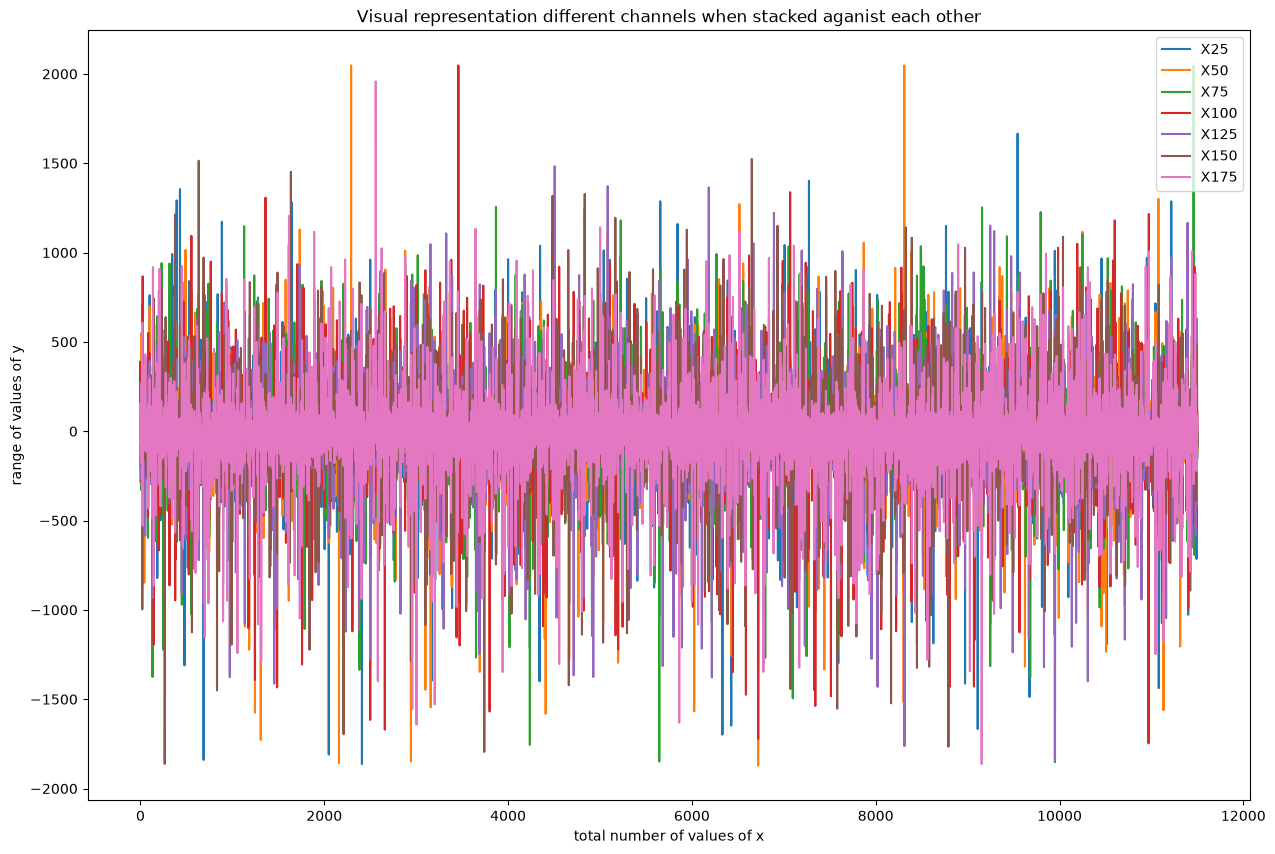

In [80]:
#plt.figure(figsize=(10,10))
#this can help of provide us the general idea of how the waves are behaving 
#fig, axs = plt.subplots(1, sharex=True, sharey=True)
plt.rcParams["figure.figsize"] = (15, 10)
data.loc[:,::25].plot()
plt.title("Visual representation different channels when stacked aganist each other")
plt.xlabel("total number of values of x")
plt.ylabel("range of values of y")
plt.show()

Here we have plotted all the waves in the same chart just have an idea how they differ from each other by the value of frequency. Though we can find most of them overlap each other.

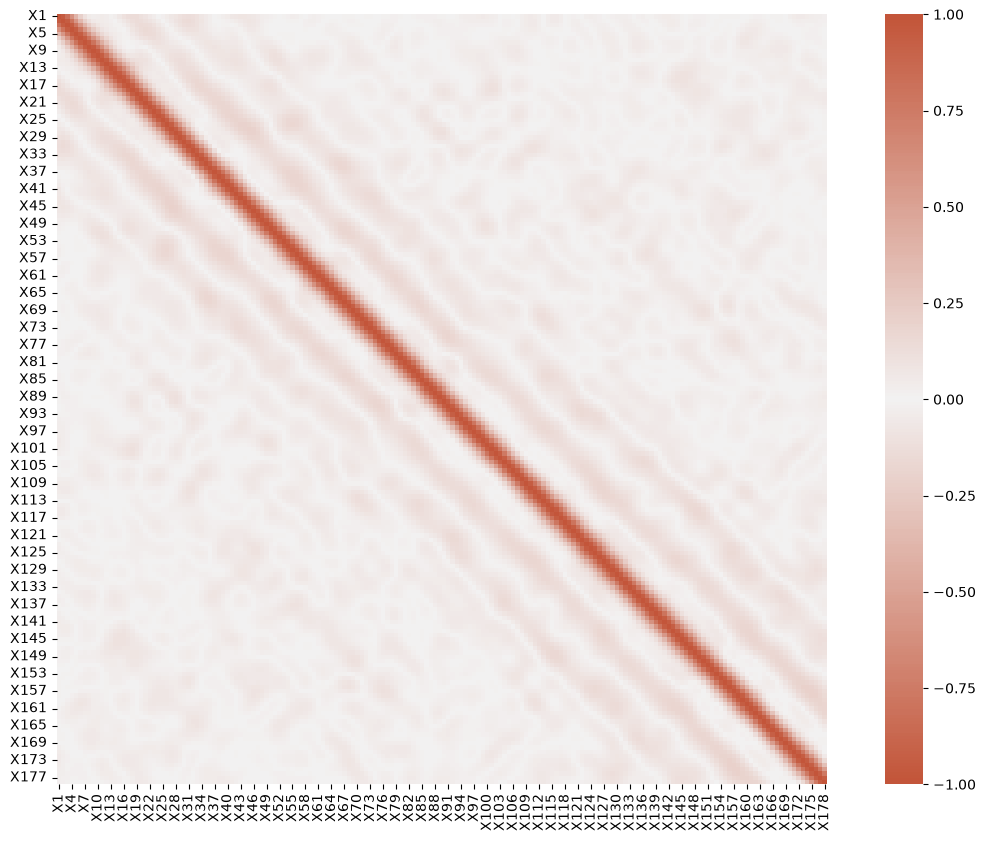

In [82]:
# Correlation Matrix
corr = data_1.corr()
ax = sns.heatmap(
    corr, 
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 20, n=300),
    square=True
)

In [36]:
data_2 = data.drop(["Unnamed"],axis=1).copy()

In [37]:
data_2["Output"]= data_2.y == 0

In [38]:
data_2["Output"] = data_2["Output"].astype(int)

In [39]:
data_2.y.value_counts()

y
4    2300
1    2300
5    2300
2    2300
3    2300
Name: count, dtype: int64

In [40]:
data_2['y'] = data_2['y'].replace([2,3,4,5],0)

In [41]:
data_2.y.value_counts() #we can see there is a mojor class imbalance problem in our dataset

y
0    9200
1    2300
Name: count, dtype: int64

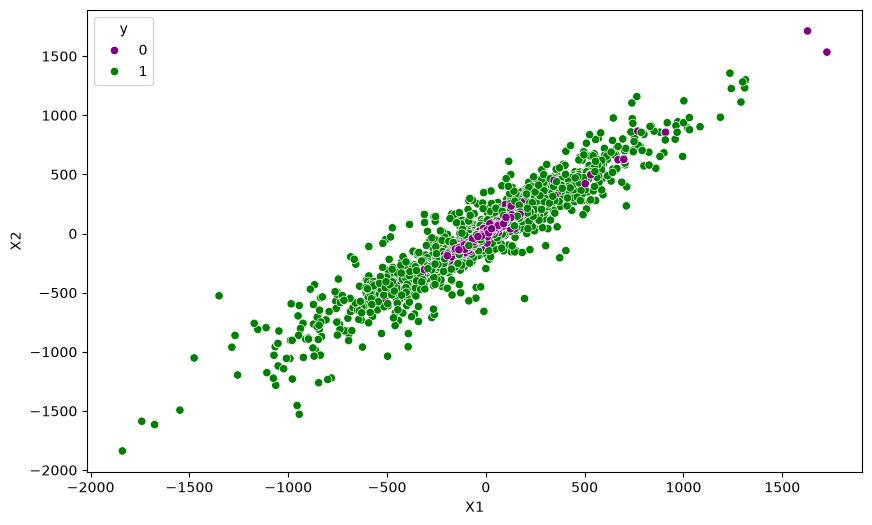

In [84]:
plt.figure(figsize=(10,6),dpi=100)
sns.despine(left=True)
sns.scatterplot(x='X1', y='X2', hue = 'y', data=data_2, palette={0: 'purple', 1: 'green'})
plt.show()
#we can see the clear class imbalance problem present here

In [43]:
data_2.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X171,X172,X173,X174,X175,X176,X177,X178,y,Output
0,135,190,229,223,192,125,55,-9,-33,-38,...,-15,-31,-77,-103,-127,-116,-83,-51,0,0
1,386,382,356,331,320,315,307,272,244,232,...,150,146,152,157,156,154,143,129,1,0
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,...,64,48,19,-12,-30,-35,-35,-36,0,0
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,...,-81,-80,-77,-85,-77,-72,-69,-65,0,0
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,...,2,-12,-32,-41,-65,-83,-89,-73,0,0


In [44]:
data_2.y.value_counts()

y
0    9200
1    2300
Name: count, dtype: int64

In [45]:
X  = data_2.drop(['Output','y'], axis=1)
y = data_2['y']

In [46]:
counter = Counter(y)
#finding out the 
print('Before',counter)
# oversampling the train dataset using SMOTE + ENN
smenn = SMOTEENN()
X_train1, y_train1 = smenn.fit_resample(X, y)

counter = Counter(y_train1)
print('After',counter)

Before Counter({0: 9200, 1: 2300})
After Counter({0: 9070, 1: 9058})


In [47]:
#so we will start with dividing it into two parts/because with this method we cannot divide it into three parts
X_train, X_test, y_train, y_test = train_test_split(X_train1,y_train1,test_size=0.4,random_state=42)

#now we will be dividing it into further to get the validation set
X_val, X_test, y_val, y_test = train_test_split(X_test,y_test,test_size=0.5,random_state=42)

In [48]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

#now we will going to scale the dataset
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [49]:
print("The shape of the training set is :{}".format(X_train.shape))
print("The shape of the testing set is :{}".format(X_test.shape))
print("The shape of the validation set is :{}".format(X_val.shape))

The shape of the training set is :(10876, 178)
The shape of the testing set is :(3626, 178)
The shape of the validation set is :(3626, 178)


# Logistic Regression

In [50]:
# STEP 2: train the model on the training set
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [51]:
from sklearn import metrics
# STEP 3: make predictions on the testing set
y_pred = logreg.predict(X_val)

# compare actual response values (y_test) with predicted response values (y_pred)
print(metrics.accuracy_score(y_val, y_pred))

0.6621621621621622


In [52]:
y_train_re = y_train.values.reshape(-1,1)
y_val_re = y_val.values.reshape(-1,1)

In [53]:
# STEP 2: train the model on the training set
logreg = LogisticRegression()
logreg.fit(X_train, y_train_re)
# STEP 3: make predictions on the testing set
y_pred = logreg.predict(X_val)

# compare actual response values (y_test) with predicted response values (y_pred)
print("The accuracy score of the model on the validation data is:{}.".format(metrics.accuracy_score(y_val_re, y_pred)*100))

#fiding out the confusion matrix of the dataset
Myconfusion = metrics.confusion_matrix(y_pred,y_val_re)
print("This is the required confusion matrix of the model:{}.".format(Myconfusion))

The accuracy score of the model on the validation data is:66.21621621621621.
This is the required confusion matrix of the model:[[1489  891]
 [ 334  912]].


In [54]:
from sklearn.metrics import classification_report
print(classification_report(y_val,y_pred))

              precision    recall  f1-score   support

           0       0.63      0.82      0.71      1823
           1       0.73      0.51      0.60      1803

    accuracy                           0.66      3626
   macro avg       0.68      0.66      0.65      3626
weighted avg       0.68      0.66      0.65      3626



In [55]:
# calculate the FPR and TPR for all thresholds of the classification
y_pred = logreg.predict(X_val)
#y_pred = y_pred[:, 1]
logit_fpr, logit_tpr, thresholds = metrics.roc_curve(y_val, y_pred)
logit_auc = metrics.roc_auc_score(y_val, y_pred)

# K-nearest neighbors

In [56]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors= 100)
knn.fit(X_train,y_train)

y_valid_preds = knn.predict_proba(X_val)
#Evaluation
precision = metrics.accuracy_score(y_pred, y_val) * 100
print("Accuracy with K-NN: {0:.2f}%".format(precision))
print(classification_report(y_val,y_pred))


Accuracy with K-NN: 66.22%
              precision    recall  f1-score   support

           0       0.63      0.82      0.71      1823
           1       0.73      0.51      0.60      1803

    accuracy                           0.66      3626
   macro avg       0.68      0.66      0.65      3626
weighted avg       0.68      0.66      0.65      3626



In [57]:
# calculate the FPR and TPR for all thresholds of the classification
y_pred = knn.predict(X_val)
#y_pred = y_pred[:, 1]
knn_fpr, knn_tpr, thresholds = metrics.roc_curve(y_val, y_pred)
knn_auc = metrics.roc_auc_score(y_val, y_pred)

# Support Vector Machine

In [58]:
from sklearn.svm import SVC

svm = SVC(gamma='auto', kernel='linear', probability=True)
svm.fit(X_train, y_train) 
y_pred = svm.predict(X_val)

#Evaluation
precision = metrics.accuracy_score(y_pred, y_val) * 100
print("Accuracy with SVM: {0:.2f}%".format(precision))


# calculate the FPR and TPR for all thresholds of the classification
probs = svm.predict_proba(X_val)
probs = probs[:, 1]
svm_fpr, svm_tpr, thresholds = metrics.roc_curve(y_val, probs)
svm_auc = metrics.roc_auc_score(y_val, probs)

Accuracy with SVM: 66.38%


In [59]:
# calculate the FPR and TPR for all thresholds of the classification
y_pred = svm.predict(X_val)
#y_pred = y_pred[:, 1]
svm_fpr, svm_tpr, thresholds = metrics.roc_curve(y_val, y_pred)
svm_auc = metrics.roc_auc_score(y_val, y_pred)

# Stochastic Gradient Descend

In [61]:
from sklearn.linear_model import SGDClassifier
from sklearn import metrics

stochg = SGDClassifier(
    loss='log_loss',
    alpha=0.1,
    random_state=42
)

stochg.fit(X_train, y_train)

y_pred = stochg.predict(X_val)

print("Stochastic Gradient Descent")

print(
    'Accuracy with stochg is: {0:.2f}%.'.format(
        metrics.accuracy_score(y_val, y_pred) * 100
    )
)

Stochastic Gradient Descent
Accuracy with stochg is: 64.59%.


In [62]:
# calculate the FPR and TPR for all thresholds of the classification
y_pred = stochg.predict(X_val)
#y_pred = y_pred[:, 1]
stochg_fpr, stochg_tpr, thresholds = metrics.roc_curve(y_val, y_pred)
stochg_auc = metrics.roc_auc_score(y_val, y_pred)

# Naive Bayes Classifier

In [63]:
from sklearn.naive_bayes import GaussianNB
naive = GaussianNB()
naive.fit(X_train,y_train)

print("Naive Bayes")
print('Accuracy with naive is:{0:.2f}%.'.format(metrics.accuracy_score(y_pred, y_val) * 100))

Naive Bayes
Accuracy with naive is:64.59%.


In [64]:
# calculate the FPR and TPR for all thresholds of the classification
y_pred = naive.predict(X_val)
#y_pred = y_pred[:, 1]
naive_fpr, naive_tpr, thresholds = metrics.roc_curve(y_val, y_pred)
naive_auc = metrics.roc_auc_score(y_val, y_pred)

# Decision Trees (DTs)

In [65]:
#now checking the accuracy on the decision tree classification
from sklearn import tree
tree_eeg = tree.DecisionTreeClassifier()
tree = tree_eeg.fit(X_train,y_train)
#predicting
y_pred = tree.predict(X_val) 
#Evaluating the model
precision = metrics.accuracy_score(y_pred,y_val)* 100
#print  the accuracy
print("Accuracy of the model by using the decision tree algorithm : {0:.2f}%".format(precision))

Accuracy of the model by using the decision tree algorithm : 93.02%


In [66]:
# calculate the FPR and TPR for all thresholds of the classification
y_pred = tree.predict(X_val)
#y_pred = y_pred[:, 1]
tree_fpr, tree_tpr, thresholds = metrics.roc_curve(y_val, y_pred)
tree_auc = metrics.roc_auc_score(y_val, y_pred)

# Random Forest Classifier

In [67]:
from sklearn.ensemble import RandomForestClassifier
random = RandomForestClassifier(max_depth=10,random_state=69)
random.fit(X_train,y_train)

#predicting
y_pred = random.predict(X_val) 
#Evaluating the model
precision = metrics.accuracy_score(y_pred,y_val)* 100
#print  the accuracy
print("Accuracy of the model by using the random algorithm : {0:.2f}%".format(precision))


Accuracy of the model by using the random algorithm : 96.61%


In [68]:
# calculate the FPR and TPR for all thresholds of the classification
y_pred = random.predict(X_val)
#y_pred = y_pred[:, 1]
random_fpr, random_tpr, thresholds = metrics.roc_curve(y_val, y_pred)
random_auc = metrics.roc_auc_score(y_val, y_pred)

# Extra-trees classifier

In [69]:
from sklearn.ensemble import ExtraTreesClassifier
extra = ExtraTreesClassifier(bootstrap=False,criterion="entropy",max_features=1.0,
                             min_samples_leaf=3,min_samples_split=20,n_estimators=100)

extra.fit(X_train,y_train)

print("Extra Trees Classifier")
#predicting
y_pred = extra.predict(X_val) 
#Evaluating the model
precision = metrics.accuracy_score(y_pred,y_val)* 100
#print  the accuracy
print("Accuracy of the model by using the extra algorithm : {0:.2f}%".format(precision))


Extra Trees Classifier
Accuracy of the model by using the extra algorithm : 98.10%


In [70]:
# calculate the FPR and TPR for all thresholds of the classification
y_pred = extra.predict(X_val)
#y_pred = y_pred[:, 1]
extra_fpr, extra_tpr, thresholds = metrics.roc_curve(y_val, y_pred)
extra_auc = metrics.roc_auc_score(y_val, y_pred)

# Gradient Boosting for classification.

In [71]:
from pandas.core.common import random_state
from sklearn.ensemble import GradientBoostingClassifier
gradient = GradientBoostingClassifier(
    n_estimators=100,learning_rate=1.0,max_depth=6,random_state=69)

gradient.fit(X_train,y_train)

print("Gradient Boosting for classification.")
#predicting
y_pred = gradient.predict(X_val) 
#Evaluating the model
precision = metrics.accuracy_score(y_pred,y_val)* 100
#print  the accuracy
print("Accuracy of the model by using the gradient algorithm : {0:.2f}%".format(precision))



Gradient Boosting for classification.
Accuracy of the model by using the gradient algorithm : 98.12%


In [72]:
# calculate the FPR and TPR for all thresholds of the classification
y_pred = gradient.predict(X_val)
#y_pred = y_pred[:, 1]
gradient_fpr, gradient_tpr, thresholds = metrics.roc_curve(y_val, y_pred)
gradient_auc = metrics.roc_auc_score(y_val, y_pred)

# XGBoost

In [73]:
from xgboost import XGBClassifier
import xgboost as xgb
xgbc = XGBClassifier()

xgbc.fit(X_train,y_train)

print("XGBoost")
#predicting
y_pred = xgbc.predict(X_val) 
#Evaluating the model
precision = metrics.accuracy_score(y_pred,y_val)* 100
#print  the accuracy
print("Accuracy of the model by using the xgbc algorithm : {0:.2f}%".format(precision))

XGBoost
Accuracy of the model by using the xgbc algorithm : 98.23%


In [74]:
# calculate the FPR and TPR for all thresholds of the classification
y_pred = xgbc.predict(X_val)
#y_pred = y_pred[:, 1]
xgbc_fpr, xgbc_tpr, thresholds = metrics.roc_curve(y_val, y_pred)
xgbc_auc = metrics.roc_auc_score(y_val, y_pred)

# Plotting the ROC Curve

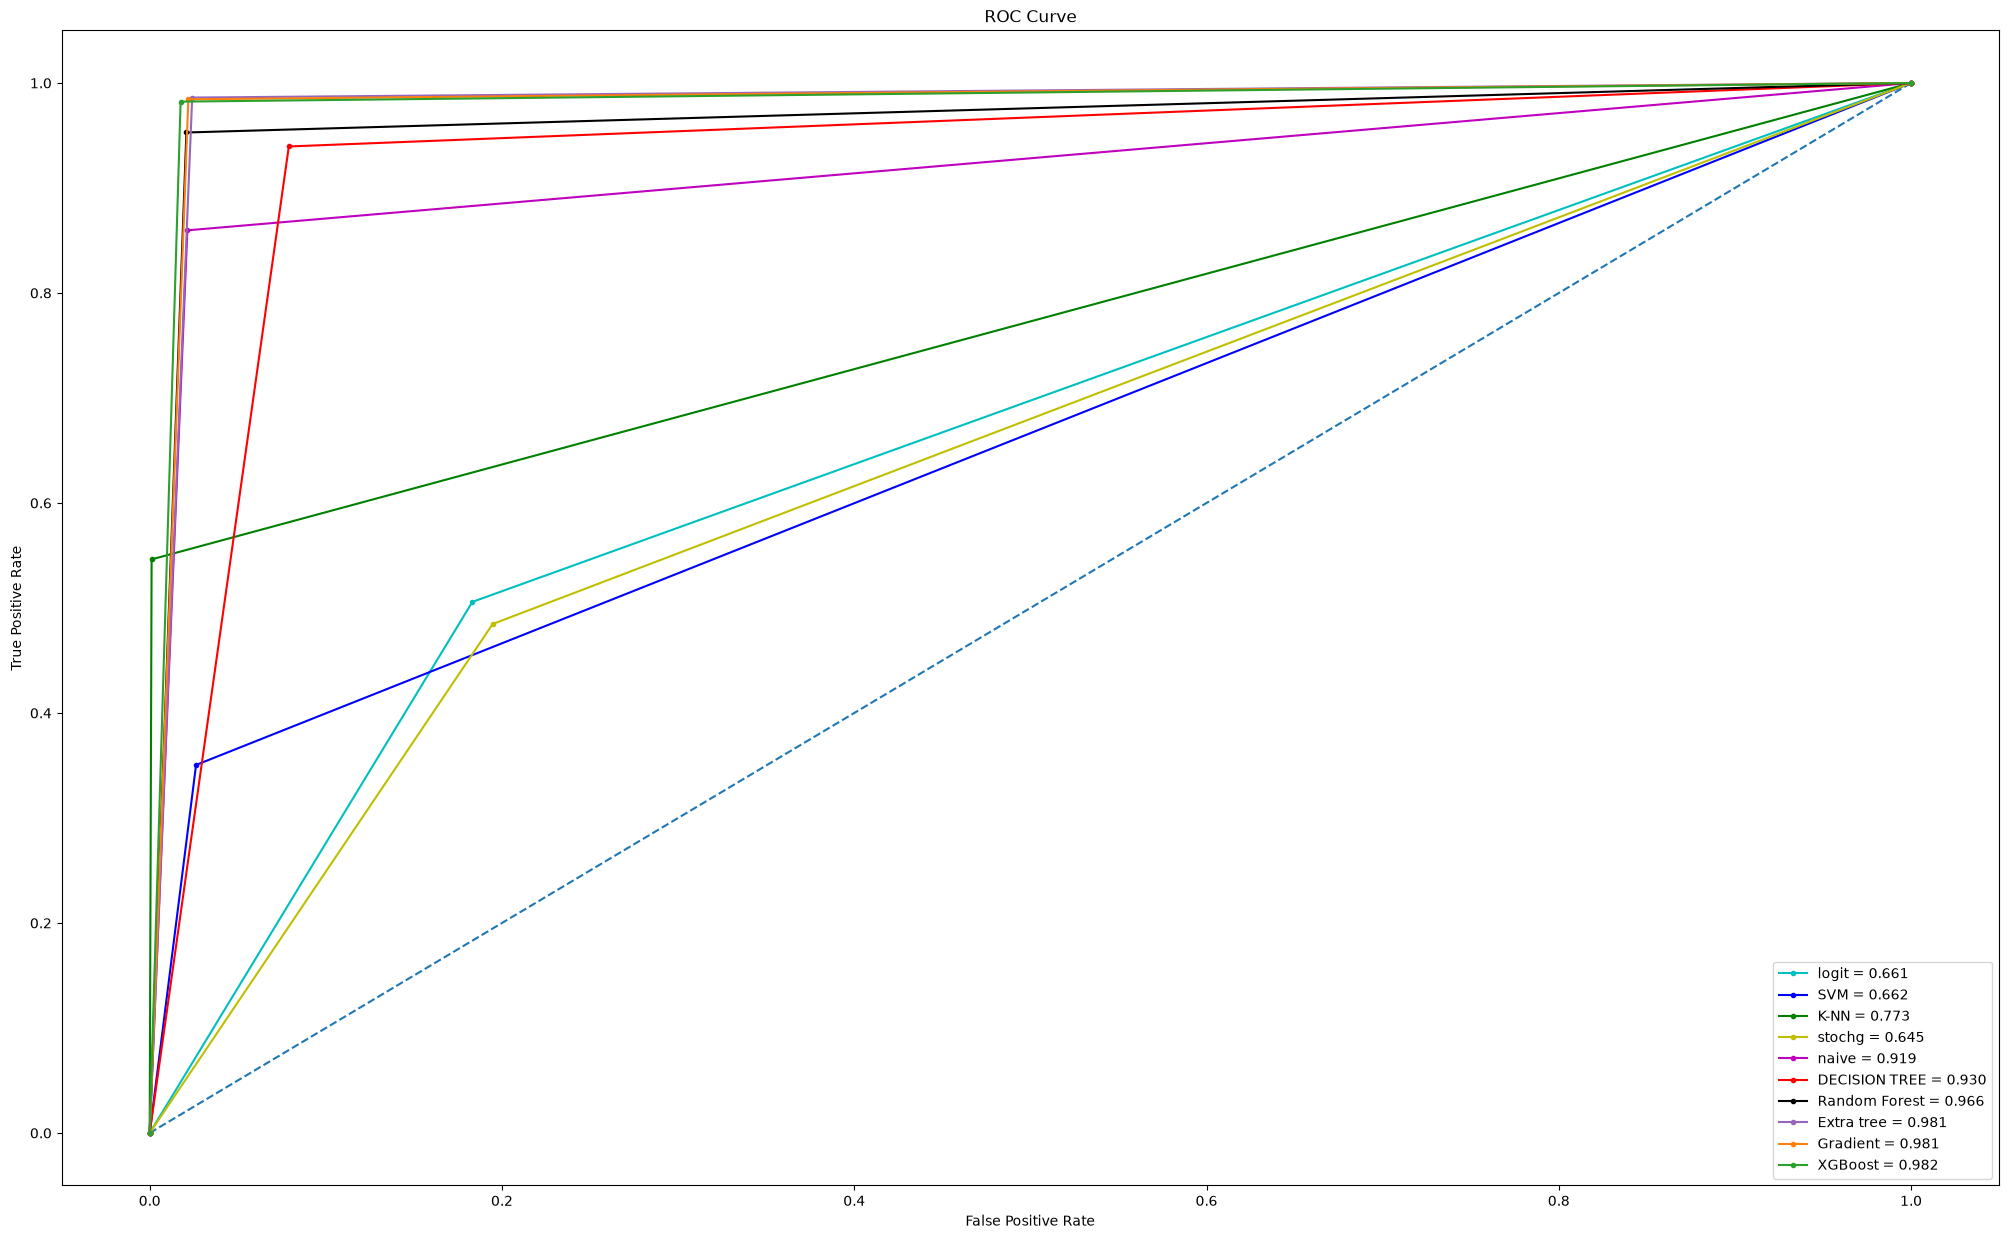

In [75]:
#ROC CURVE
plt.title('ROC Curve')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(logit_fpr, logit_tpr, 'c', marker='.', label = 'logit = %0.3f' % logit_auc )
plt.plot(svm_fpr, svm_tpr, 'b', marker='.', label = 'SVM = %0.3f' % svm_auc )
plt.plot(knn_fpr, knn_tpr, 'g', marker='.', label = 'K-NN = %0.3f' % knn_auc)
plt.plot(stochg_fpr, stochg_tpr, 'y', marker='.', label = 'stochg = %0.3f' % stochg_auc)
plt.plot(naive_fpr, naive_tpr, 'm', marker='.', label = 'naive = %0.3f' % naive_auc)
plt.plot(tree_fpr, tree_tpr, 'r', marker='.',label = 'DECISION TREE = %.3f' % tree_auc)
plt.plot(random_fpr, random_tpr, 'k', marker='.',label = 'Random Forest = %.3f' % random_auc)
plt.plot(extra_fpr, extra_tpr, 'C4', marker='.',label = 'Extra tree = %.3f' % extra_auc)
plt.plot(gradient_fpr, gradient_tpr, 'C1', marker='.',label = 'Gradient = %.3f' % gradient_auc)
plt.plot(xgbc_fpr, xgbc_tpr, 'C2', marker='.',label = 'XGBoost = %.3f' % xgbc_auc)
plt.legend(loc = 'lower right')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

# **Contact: Shayanrokhva1999@gmail.com**